In [2]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict , Annotated

from dotenv import load_dotenv
from langchain_groq import ChatGroq 
from langchain_core.messages import BaseMessage , HumanMessage , SystemMessage
import os


In [3]:
model = ChatGroq(model = 'llama-3.3-70b-versatile' , api_key = os.getenv("GROQ_API_KEY"))

In [4]:
# ------------------------ New -------------------------
from langgraph.graph.message import add_messages


class ChatClass(TypedDict):

    message : Annotated[list[BaseMessage] , add_messages] 

In [5]:
def response(state:ChatClass):

    prompt = state['message']

    res = model.invoke(prompt)

    return {'message':[res]}

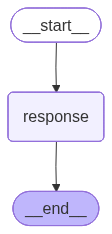

In [6]:
graph = StateGraph(ChatClass)

graph.add_node('response',response)

graph.add_edge(START , 'response')
graph.add_edge('response' , END) 

wf = graph.compile()
wf

# Ask Anything

In [7]:
ques = input("Ask ANything")

inp = {
    'message' : [HumanMessage(content = ques)]
}

out = wf.invoke(inp)
(out['message'][1]).content

'The capital of Sweden is Stockholm.'